# 1- Importing packages

In [ ]:
# import data processing and visualisation libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# import image processing libraries
import cv2
from PIL import Image

# import tensorflow and keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array,load_img
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import os
import random

#import from sklearn
from sklearn.model_selection import train_test_split

# import dataset

In [2]:
DATA_DIR = "/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train"

# The content of training data

In [3]:
print(os.listdir(DATA_DIR)[:])

['N', 'R', 'space', 'B', 'I', 'del', 'F', 'H', 'E', 'U', 'M', 'X', 'K', 'Q', 'Y', 'S', 'G', 'A', 'O', 'T', 'V', 'Z', 'C', 'P', 'L', 'W', 'D', 'nothing', 'J']


# Checking for the corrupted data and the extentions of images in dataset  

In [4]:
def check_corruption(Training_data=DATA_DIR ):
    corrupted_images = []
    extentions = []
    
    sample_images = []
    
    num_samples_per_class = 1  # عدد الصور لكل class
    
    for class_name in os.listdir(Training_data):
        class_path = os.path.join(Training_data, class_name)
        if not os.path.isdir(class_path):
            continue
    
        class_imgs = []
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            root, extention = os.path.splitext(img_path)
            if extention not in extentions:
                extentions.append(extention)
            
            try:
                if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img = Image.open(img_path)
                    img.verify()
                    class_imgs.append(img_path)
            except Exception as es:
                corrupted_images.append(img_path)
                print(f"corrupted image path: {img_path}")
    
        # اختيار أكثر من صورة لكل class
        if class_imgs:
            sample_images.extend(random.sample(class_imgs, min(num_samples_per_class, len(class_imgs))))
    
    print(f"Number of corrupted images: {len(corrupted_images)}")
    print(f"Extensions found: {extentions}")

# Data Extraction

In [5]:
categories={0:'A',
           1:'B',
           2:'C',
           3:'D',
           4:'E',
            5:'F',
            6:'G',
            7:'H',
            8:'I',
            9:'J',
            10:'K',
            11:'L',
            12:'M',
            13:'N',
            14:'O',
            15:'P',
            16:'Q', 
            17:'R',
            18:'S',
            19:'T',
            20:'U',
            21:'V',
            22:'W',
            23:'X',
            24:'Y',
            25:'Z',
            26:'del',
            27:'nothing',
            28:'space'
           
           }

In [6]:
#function to store the image with the full path for easy reaching it during the training  
def add_classNames_prefix(df, col_name, base_path):
    df[col_name] = df.apply(lambda x: os.path.join(base_path, categories[x["Category"]], x["FileName"]), axis=1)
    return df
#list to lis the image name 
file_names_list=[]
#list to list the category of each image 
categories_list=[]

for category in categories:
    filenames=os.listdir(os.path.join(DATA_DIR,categories[category]))
    file_names_list+=filenames
    categories_list+=[category]*len(filenames)

df1=pd.DataFrame({"FileName":file_names_list,"Category":categories_list})
df1=add_classNames_prefix(df1,"FileName",DATA_DIR)

In [7]:
df1

,FileName,Category
0,/kaggle/input/aslamerican-sign-language-aplhab...,0
1,/kaggle/input/aslamerican-sign-language-aplhab...,0
2,/kaggle/input/aslamerican-sign-language-aplhab...,0
3,/kaggle/input/aslamerican-sign-language-aplhab...,0
4,/kaggle/input/aslamerican-sign-language-aplhab...,0
...,...,...
223069,/kaggle/input/aslamerican-sign-language-aplhab...,28
223070,/kaggle/input/aslamerican-sign-language-aplhab...,28
223071,/kaggle/input/aslamerican-sign-language-aplhab...,28
223072,/kaggle/input/aslamerican-sign-language-aplhab...,28


# Data Exploration 

In [8]:
# shuffled dataframe for data expolation
df=pd.DataFrame({"FileName":file_names_list,"Category":categories_list})
df=add_classNames_prefix(df1,"FileName",DATA_DIR)
df = df.sample(frac=1).reset_index(drop=True)


 Showing images from classes in training dataset 

# Data preprocessing

1-showing the original size of images 

In [9]:
img_shapes = []

for path in df["FileName"]:  
    img = cv2.imread(path)    
    if img is not None:       
        img_shapes.append(img.shape)  

print(set(img_shapes)) 


{(400, 400, 3), (200, 150, 3), (200, 200, 3), (480, 640, 3), (1920, 1920, 3), (720, 1280, 3)}


2- function to resize images 

In [10]:
train_dfs = []
test_dfs = []
val_dfs = []

for category in df1["Category"].unique():
    df_cat = df1[df1["Category"] == category]

    # train/test split
    train_cat, test_cat = train_test_split(df_cat, test_size=0.2, random_state=42)
    
    # train/validation split
    train_cat, val_cat = train_test_split(train_cat, test_size=0.1, random_state=42)

    train_dfs.append(train_cat)
    test_dfs.append(test_cat)
    val_dfs.append(val_cat)

# ندمجهم
train_df = pd.concat(train_dfs).reset_index(drop=True)
test_df = pd.concat(test_dfs).reset_index(drop=True)
val_df = pd.concat(val_dfs).reset_index(drop=True)

print("Train:", len(train_df), "Test:", len(test_df), "Val:", len(val_df))



Train: 160589 Test: 44627 Val: 17858


In [11]:
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
val_df = val_df.sample(frac=1, random_state=42).reset_index(drop=True)


In [12]:
def load_data_from_df(df, img_size=64, grayscale=True):
    data = []
    labels = []

    classes = sorted(df["Category"].unique())
    class_to_index = {cls: idx for idx, cls in enumerate(classes)}

    for _, row in df.iterrows():
        try:
            if grayscale:
                img = cv2.imread(row["FileName"], cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (img_size, img_size))
                img = img / 255.0
                img = np.expand_dims(img, axis=-1)
            else:
                img = cv2.imread(row["FileName"])
                img = cv2.resize(img, (img_size, img_size))
                img = img / 255.0

            data.append(img)
            labels.append(class_to_index[row["Category"]])
        except:
            pass
    
    return np.array(data, dtype="float32"), np.array(labels), classes


In [13]:
# processing training data
X_train,y_train,train_classes=load_data_from_df(train_df)


In [14]:
y_train

array([ 9,  9, 25, ..., 23, 25, 21])

In [15]:
train_classes


[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28]

In [16]:
#processing test data
X_test,y_test,test_classes=load_data_from_df(test_df)

In [17]:
#processing vaidation data
X_validtaion,y_validation,validation_classes=load_data_from_df(val_df)

# showing an image after applying the preproccing   

3- convert labels into one hot encodded classes

In [18]:
y_train = to_categorical(y_train, num_classes=len(train_classes))

In [37]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [19]:
y_test = to_categorical(y_test, num_classes=len(test_classes))

In [20]:
y_validation = to_categorical(y_validation, num_classes=len(validation_classes))

# Display some images after preprocessing 

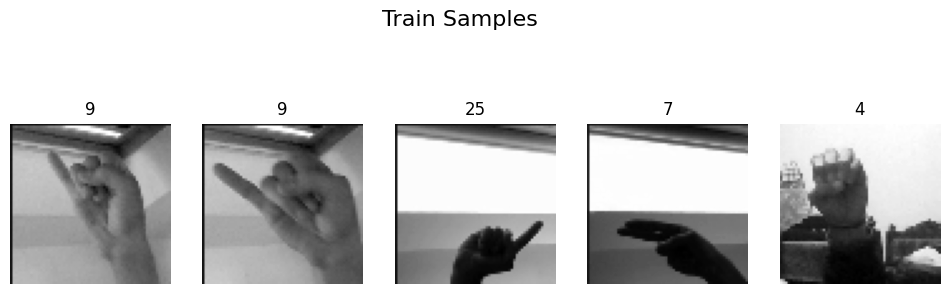

In [21]:
def show_samples(X, y, classes, n=5, title="Samples"):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(X[i].squeeze(), cmap="gray")  # squeeze() لو الصور grayscale
        # Decode the one-hot encoded label back to an integer index
        class_index = np.argmax(y[i])
        plt.title(classes[class_index])
        plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.show()

# عرض عينات من Train
show_samples(X_train, y_train, train_classes, n=5, title="Train Samples")

# Building model

In [22]:
from keras.models import Sequential
from keras.layers import Conv2D ,MaxPooling2D, Activation, Dense,BatchNormalization,Dropout,Flatten
from keras.callbacks import EarlyStopping , ReduceLROnPlateau,ModelCheckpoint
import tensorflow as tf
import keras

In [27]:
#model
CNN_model= Sequential()

#Block1
CNN_model.add(Conv2D(32,(3,3),padding="same",input_shape=(64,64,1)))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation('relu'))
CNN_model.add(Conv2D(32,(3,3),padding="same"))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation("relu"))
CNN_model.add(MaxPooling2D(pool_size=(2,2)))
CNN_model.add(Dropout(0.2))

#block2
CNN_model.add(Conv2D(64,(3,3),padding="same"))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation('relu'))
CNN_model.add(Conv2D(64,(3,3),padding="same"))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation("relu"))
CNN_model.add(MaxPooling2D(pool_size=(2,2)))
CNN_model.add(Dropout(0.25))

#block3
CNN_model.add(Conv2D(128,(3,3),padding="same"))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation('relu'))
CNN_model.add(Conv2D(128,(3,3),padding="same"))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation("relu"))
CNN_model.add(MaxPooling2D(pool_size=(2,2)))
CNN_model.add(Dropout(0.3))

#flatten 
CNN_model.add(Flatten())

#fully coneected layer 
CNN_model.add(Dense(512,activation="relu"))
CNN_model.add(Dropout(0.2))
CNN_model.add(Dense(128,activation='relu'))
CNN_model.add(Dropout(0.25))

#output layer 
CNN_model.add(Dense(29,activation="softmax"))

CNN_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 128)    │             

 Total params: 4,552,445 (17.37 MB)

 Trainable params: 4,551,549 (17.36 MB)

 Non-trainable params: 896 (3.50 KB)

In [45]:
#optimzer
CNN_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [46]:
#callbacks
callback=[
tf.keras.callbacks.ModelCheckpoint ("best.h5",save_best_only=True,monitor='val_accuracy'),
tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy',patience=3,factor=0.5),
tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=6,restore_best_weights=True)]

In [48]:
#fitting model
histroy=CNN_model.fit(X_train,y_train,batch_size=64,epochs=40,validation_data=(X_validtaion,y_validation),callbacks=callback)

Epoch 1/40
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 85s 29ms/step - accuracy: 0.1510 - loss: 2.9597 - val_accuracy: 0.7074 - val_loss: 1.0036 - learning_rate: 1.0000e-04
Epoch 2/40
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 66s 26ms/step - accuracy: 0.6546 - loss: 1.0796 - val_accuracy: 0.8927 - val_loss: 0.3680 - learning_rate: 1.0000e-04
Epoch 3/40
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 65s 26ms/step - accuracy: 0.8294 - loss: 0.5273 - val_accuracy: 0.9549 - val_loss: 0.1635 - learning_rate: 1.0000e-04
Epoch 4/40
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 65s 26ms/step - accuracy: 0.8981 - loss: 0.3158 - val_accuracy: 0.9626 - val_loss: 0.1200 - learning_rate: 1.0000e-04
Epoch 5/40
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 65s 26ms/step - accuracy: 0.9282 - loss: 0.2216 - val_accuracy: 0.9803 - val_loss: 0.0686 - learning_rate: 1.0000e-04
Epoch 6/40
2510/2510 ━━━━━━━━━━━━━━━━━━━━ 65s 26ms/step - accuracy: 0.9468 - loss: 0.1617 - val_accuracy: 0.9845 - val_loss: 0.0540 - learning_rate: 1.0000e-04
Epoch 7/40
2510/2510 ━━━━━━━━━━━━━━━━━━━

In [ ]:
metrics = pd.DataFrame(histroy.history)
print("The model metrics are")
metrics

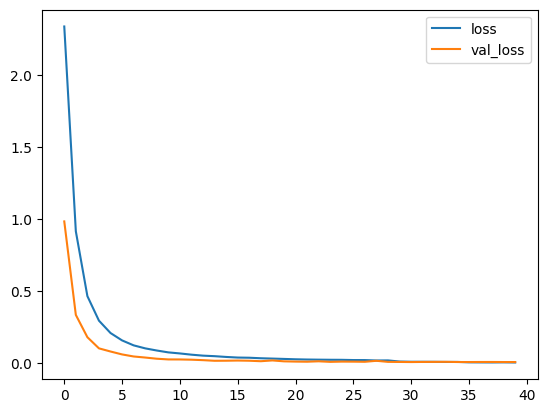

In [51]:
metrics[['loss','val_loss']].plot()
plt.show()

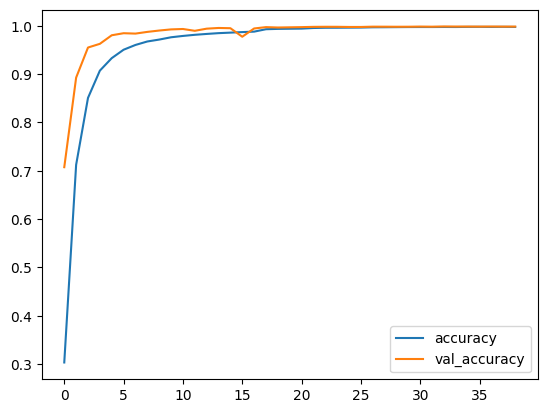

In [53]:
metrics[['accuracy','val_accuracy']].plot()
plt.show()

In [49]:
CNN_model.evaluate(X_test,y_test,verbose=0)

[0.010050508193671703, 0.997512698173523]

In [50]:
test_loss, test_acc = CNN_model.evaluate(X_test, y_test)


1395/1395 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9980 - loss: 0.0081


In [59]:
y_pred = CNN_model.predict(X_test)


1395/1395 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step


In [60]:
import numpy as np

y_pred_classes = np.argmax(y_pred, axis=1)   
y_true = np.argmax(y_test, axis=1)           


In [ ]:
sample=CNN_model.predict(X_test[0])

In [61]:
from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_true, y_pred_classes))


Test Accuracy: 0.9975127165169068


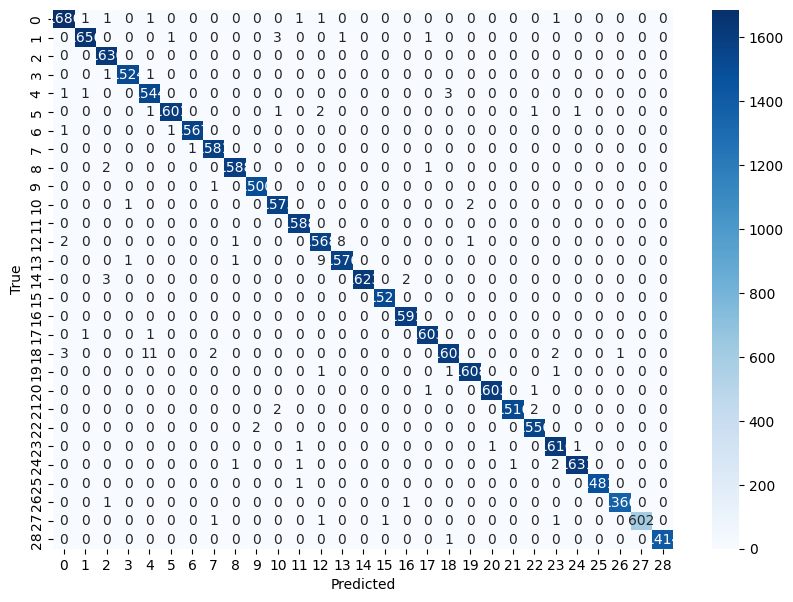

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [63]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred_classes))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1692
           1       1.00      1.00      1.00      1662
           2       1.00      1.00      1.00      1630
           3       1.00      1.00      1.00      1526
           4       0.99      1.00      0.99      1549
           5       1.00      1.00      1.00      1607
           6       1.00      1.00      1.00      1569
           7       1.00      1.00      1.00      1582
           8       1.00      1.00      1.00      1591
           9       1.00      1.00      1.00      1501
          10       1.00      1.00      1.00      1576
          11       1.00      1.00      1.00      1588
          12       0.99      0.99      0.99      1580
          13       0.99      0.99      0.99      1587
          14       1.00      1.00      1.00      1628
          15       1.00      1.00      1.00      1521
          16       1.00      1.00      1.00      1591
          17       1.00    

In [40]:
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("validation shape:")
print("num_classes:", len(train_classes))
 

y_train shape: (160589, 29)
y_test shape: (44627, 29)
num_classes: 29


In [41]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (160589, 64, 64, 1)
X_test shape: (44627, 64, 64, 1)
